# Credit Scoring: EDA, моделирование и калибровка

**Задача.** Предсказать вероятность того, что клиент допустит серьёзную просрочку
(90+ дней) в течение ближайших двух лет — целевой признак `SeriousDlqin2yrs`.
Датасет — Kaggle *Give Me Some Credit*.

**План ноутбука:**
1. Загрузка данных и базовый EDA.
2. Корректное разделение на train/val/test **до** любых статистик по таргету.
3. Заполнение пропусков по статистикам, посчитанным **только на train** (без утечки).
4. Feature engineering и обоснование каждого признака.
5. Подбор гиперпараметров CatBoost через Optuna.
6. Финальная модель + отбор признаков по importance.
7. **Калибровка вероятностей** (isotonic) и проверка на calibration curve.
8. **Бизнес-метрики**: KS, Gini, confusion matrix на оптимальном пороге, ожидаемая прибыль.
9. **SHAP-анализ** для интерпретации.
10. **Score-карта**: перевод вероятности в банковский балл.
11. Сохранение всех артефактов для API/дашборда.


## 1. Импорты и фиксация сидов

Фиксируем все источники случайности, чтобы результаты воспроизводились.

In [1]:
import json
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Фиксируем все сиды до первого вызова случайных функций
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Пути к артефактам — единая точка правды
DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Загрузка данных и базовый EDA

In [2]:
train = pd.read_csv(DATA_DIR / "cs-training.csv", index_col=0)
test_kaggle = pd.read_csv(DATA_DIR / "cs-test.csv", index_col=0)  # holdout от Kaggle, без меток

print("Train:", train.shape)
print("Kaggle test (без меток):", test_kaggle.shape)
train.head()

Train: (150000, 11)
Kaggle test (без меток): (101503, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,"9,120.0000",13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,"2,600.0000",4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,"3,042.0000",2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,"3,300.0000",5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,"63,588.0000",7,0,1,0,0.0000


**Важное замечание.** В Kaggle-сете `cs-test.csv` **нет** меток — это hold-out для
лидерборда. Поэтому свой test для оценки качества будем выделять **из тренировочного**
файла, а Kaggle-test трогать не будем (только в самом конце для submission, если потребуется).

In [3]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,"150,000.0000","150,000.0000","150,000.0000","150,000.0000","150,000.0000","120,269.0000","150,000.0000","150,000.0000","150,000.0000","150,000.0000","146,076.0000"
mean,0.0668,6.0484,52.2952,0.4210,353.0051,"6,670.2212",8.4528,0.2660,1.0182,0.2404,0.7572
std,0.2497,249.7554,14.7719,4.1928,"2,037.8185","14,384.6742",5.1460,4.1693,1.1298,4.1552,1.1151
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0299,41.0000,0.0000,0.1751,"3,400.0000",5.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.1542,52.0000,0.0000,0.3665,"5,400.0000",8.0000,0.0000,1.0000,0.0000,0.0000
75%,0.0000,0.5590,63.0000,0.0000,0.8683,"8,249.0000",11.0000,0.0000,2.0000,0.0000,1.0000
max,1.0000,"50,708.0000",109.0000,98.0000,"329,664.0000","3,008,750.0000",58.0000,98.0000,54.0000,98.0000,20.0000


Что бросается в глаза:

- Сильный **дисбаланс**: дефолтов всего ≈6.7%.
- `RevolvingUtilizationOfUnsecuredLines` имеет max=50708 — явные выбросы (по смыслу это доля от 0 до 1, ну максимум до нескольких).
- `DebtRatio` тоже улетает в космос (max=329664), хотя должен быть ограничен разумной величиной.
- Возраст имеет min=0 — явная ошибка ввода.
- Просрочки 30/60/90 имеют значения 96 и 98 — это special codes, означающие «нет данных» или «не применимо» (известная особенность датасета).

Деревья (CatBoost) к выбросам устойчивы, но для feature engineering это надо учитывать.

In [4]:
print(train["SeriousDlqin2yrs"].value_counts(normalize=True))
print()
print("Пропуски:")
print(train.isnull().sum())

SeriousDlqin2yrs
0   0.9332
1   0.0668
Name: proportion, dtype: float64

Пропуски:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


Пропуски только в `MonthlyIncome` (≈20%) и `NumberOfDependents` (≈2.6%). Сам факт пропуска
дохода — потенциально сильный сигнал (клиент не указал/не смог подтвердить),
поэтому добавим бинарный индикатор пропуска.

## 3. Сплит до любых трансформаций

**Почему именно так.** Если посчитать медиану/моду на всём `train`, а потом сделать сплит,
то значения, попавшие в test/val, повлияли на статистики, использованные для их же
заполнения. Это утечка данных (data leakage). Поэтому:

1. Сначала отделяем target.
2. Делаем стратифицированный сплит train/val/test.
3. Все статистики (медиана дохода, мода иждивенцев) считаем **только на X_train**
   и применяем их к X_val и X_test.

In [5]:
from sklearn.model_selection import train_test_split

y = train["SeriousDlqin2yrs"]
X = train.drop(columns=["SeriousDlqin2yrs"])

# 70/15/15: сначала отделяем 15% test, потом из оставшихся 85% берём ~17.65% на val,
# что в исходных долях даёт ровно 15%.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, stratify=y_trainval, random_state=SEED
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Доля дефолтов в train: {y_train.mean():.4f}")
print(f"Доля дефолтов в val:   {y_val.mean():.4f}")
print(f"Доля дефолтов в test:  {y_test.mean():.4f}")

Train: (104996, 10), Val: (22504, 10), Test: (22500, 10)
Доля дефолтов в train: 0.0668
Доля дефолтов в val:   0.0668
Доля дефолтов в test:  0.0668


## 4. Заполнение пропусков (статистики — только на train)

- `MonthlyIncome` → медиана. Среднее не подходит: распределение тяжелохвостое
  (max=3 008 750 при медиане ~5 400), несколько выбросов сильно сместили бы среднее.
- `NumberOfDependents` → мода (фактически 0).
- Для обоих признаков добавляем бинарный индикатор пропуска. Особенно важен
  `MonthlyIncome_missing`: сам факт «не указал доход» в скоринге — сигнал.

In [6]:
# Считаем статистики ТОЛЬКО на train
income_median = float(X_train["MonthlyIncome"].median())
dependents_mode = int(X_train["NumberOfDependents"].mode().iloc[0])

print(f"Медиана дохода (train): {income_median}")
print(f"Мода числа иждивенцев (train): {dependents_mode}")


def fill_missing(df: pd.DataFrame, income_median: float, dependents_mode: int) -> pd.DataFrame:
    """Заполняем пропуски константами, посчитанными на train.

    Важное: добавляем индикаторы пропуска ДО заполнения, иначе потеряем сигнал.
    Возвращаем копию, чтобы не мутировать исходный DataFrame.
    """
    df = df.copy()
    df["MonthlyIncome_missing"] = df["MonthlyIncome"].isnull().astype(int)
    df["NumberOfDependents_missing"] = df["NumberOfDependents"].isnull().astype(int)
    df["MonthlyIncome"] = df["MonthlyIncome"].fillna(income_median)
    df["NumberOfDependents"] = df["NumberOfDependents"].fillna(dependents_mode)
    return df


X_train = fill_missing(X_train, income_median, dependents_mode)
X_val   = fill_missing(X_val,   income_median, dependents_mode)
X_test  = fill_missing(X_test,  income_median, dependents_mode)

# Сохраняем статистики, чтобы API мог переиспользовать их на новых данных
with open(MODELS_DIR / "fill_values.json", "w") as f:
    json.dump({"income_median": income_median, "dependents_mode": dependents_mode}, f)

Медиана дохода (train): 5400.0
Мода числа иждивенцев (train): 0


## 5. Feature engineering

Каждая фича — это гипотеза о том, что в данных есть нелинейная зависимость, которую
дереву легче выучить, если её явно подсказать.

| Фича | Гипотеза |
|---|---|
| `TotalPastDue` | Суммарное число просрочек (30+60+90 дней) — общий уровень платёжной дисциплины. |
| `Has90DaysLate` | Бинарный флаг «были ли вообще серьёзные просрочки». Порог-эффект: одна просрочка 90+ — это уже совсем другой профиль риска. |
| `MonthlyIncomePerPerson` | Прокси к располагаемому доходу: доход на члена семьи. |
| `AgeRisk` | Молодые (<25) и пожилые (>65) исторически более рискованны: первые — без кредитной истории, вторые — с падением дохода после выхода на пенсию. |

In [7]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Создаём produced features. Никаких статистик по таргету тут нет — функция чистая."""
    df = df.copy()
    df["TotalPastDue"] = (
        df["NumberOfTime30-59DaysPastDueNotWorse"]
        + df["NumberOfTime60-89DaysPastDueNotWorse"]
        + df["NumberOfTimes90DaysLate"]
    )
    df["Has90DaysLate"] = (df["NumberOfTimes90DaysLate"] > 0).astype(int)
    # +1 в знаменателе — чтобы не делить на ноль для одиноких
    df["MonthlyIncomePerPerson"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)
    df["AgeRisk"] = ((df["age"] < 25) | (df["age"] > 65)).astype(int)
    return df


X_train = add_features(X_train)
X_val   = add_features(X_val)
X_test  = add_features(X_test)

print("Финальные колонки:")
print(X_train.columns.tolist())

Финальные колонки:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing', 'NumberOfDependents_missing', 'TotalPastDue', 'Has90DaysLate', 'MonthlyIncomePerPerson', 'AgeRisk']


## 6. Подбор гиперпараметров CatBoost через Optuna

**Что мы фиксируем и почему:**
- `iterations=500` — потолок числа деревьев. Реальное число определит early stopping.
- `eval_metric='AUC'` — метрика, по которой Optuna и early stopping принимают решения.
- `auto_class_weights='Balanced'` — компенсирует дисбаланс 6.7% / 93.3%.
- `od_type='Iter'`, `od_wait=20` — early stopping: остановиться, если 20 итераций подряд метрика на val не улучшается. Это защита от переобучения.

**Что варьирует Optuna:**
- `learning_rate` — скорость обучения, log-uniform от 0.01 до 0.3.
- `depth` — глубина деревьев CatBoost (4–10).
- `l2_leaf_reg` — L2-регуляризация на листах.
- `border_count` — число бакетов для дискретизации фичей.
- `random_strength` — амплитуда шума, добавляемого к скору при выборе сплита (регуляризация).
- `bagging_temperature` — параметр Bayesian bootstrap: 0 = детерминированно, 1 = веса объектов сэмплируются из Exp(1), >1 = ещё больше шума. Это ещё один регуляризатор.

In [8]:
import catboost as cb
import optuna
from sklearn.metrics import roc_auc_score

# Optuna по дефолту шумит логами в stderr — приглушаем
optuna.logging.set_verbosity(optuna.logging.WARNING)

FIXED_PARAMS = {
    "iterations": 500,
    "eval_metric": "AUC",
    "auto_class_weights": "Balanced",
    "random_seed": SEED,
    "od_type": "Iter",
    "od_wait": 20,
    "verbose": False,
}


def objective(trial: "optuna.Trial") -> float:
    """Целевая функция Optuna — максимизируем ROC-AUC на val."""
    params = {
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth":               trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "border_count":        trial.suggest_int("border_count", 32, 255),
        "random_strength":     trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
    }
    params.update(FIXED_PARAMS)

    model = cb.CatBoostClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=20,
        verbose=False,
    )
    pred = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, pred)


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Best AUC (val): {study.best_value:.4f}")
print(f"Best params:    {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best AUC (val): 0.8732
Best params:    {'learning_rate': 0.04708057738655937, 'depth': 6, 'l2_leaf_reg': 9.36830360189613, 'border_count': 235, 'random_strength': 9.280861491773642, 'bagging_temperature': 0.9938772792799193}


## 7. Финальная модель и отбор признаков

Обучаем модель на лучших параметрах, смотрим feature importance, отбираем признаки
с importance ≥ 1% (порог не магический — настройка под этот датасет, на больших
датасетах можно делать строже).

In [9]:
best_params = {**study.best_params, **FIXED_PARAMS}

with open(MODELS_DIR / "best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

final_model = cb.CatBoostClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20,
    verbose=100,
)

test_auc_full = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f"\nTest ROC-AUC (полный набор признаков): {test_auc_full:.4f}")
print(f"|AUC_test - AUC_val| = {abs(study.best_value - test_auc_full):.4f}  -> переобучения нет")

0:	test: 0.8082987	best: 0.8082987 (0)	total: 15.7ms	remaining: 7.84s
100:	test: 0.8680281	best: 0.8680281 (100)	total: 1.71s	remaining: 6.77s
200:	test: 0.8705298	best: 0.8705539 (199)	total: 3.12s	remaining: 4.64s
300:	test: 0.8723129	best: 0.8723239 (299)	total: 4.54s	remaining: 3s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.8731942598
bestIteration = 358

Shrink model to first 359 iterations.

Test ROC-AUC (полный набор признаков): 0.8719
|AUC_test - AUC_val| = 0.0013  -> переобучения нет


In [10]:
fi_df = final_model.get_feature_importance(prettified=True)
fi_df.columns = ["feature", "importance"]
print(fi_df.to_string(index=False))

                             feature  importance
RevolvingUtilizationOfUnsecuredLines     27.4088
                        TotalPastDue     25.1128
                       Has90DaysLate      7.0997
                           DebtRatio      6.1958
                                 age      5.8198
NumberOfTime60-89DaysPastDueNotWorse      4.3665
     NumberOfOpenCreditLinesAndLoans      4.3599
        NumberRealEstateLoansOrLines      4.0493
             NumberOfTimes90DaysLate      3.4376
                       MonthlyIncome      3.1100
              MonthlyIncomePerPerson      2.6005
NumberOfTime30-59DaysPastDueNotWorse      2.5087
                             AgeRisk      1.6619
               MonthlyIncome_missing      1.3920
                  NumberOfDependents      0.7180
          NumberOfDependents_missing      0.1586


**Что отбрасываем и почему:**

- `NumberOfTime30-59DaysPastDueNotWorse` и `NumberOfTime60-89DaysPastDueNotWorse` — полностью покрыты `TotalPastDue`.
- `NumberOfDependents` — слабый сигнал, эффект уже учтён через `MonthlyIncomePerPerson`.
- `NumberOfDependents_missing` — практически не влияет (importance ≈ 0.1%).
- `AgeRisk` — бинарная огрубление сырого `age`, который сам по себе сильнее.

Оставляем признаки с importance ≥ 1%.

In [11]:
# Динамический отбор: всё, что важнее 1%
selected_features = fi_df[fi_df["importance"] >= 1.0]["feature"].tolist()
print(f"Отобрано {len(selected_features)} признаков:")
for f in selected_features:
    print(f"  - {f}")

X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

model_sel = cb.CatBoostClassifier(**best_params)
model_sel.fit(
    X_train_sel, y_train,
    eval_set=(X_val_sel, y_val),
    early_stopping_rounds=20,
    verbose=False,
)

test_auc_sel = roc_auc_score(y_test, model_sel.predict_proba(X_test_sel)[:, 1])
print(f"\nTest ROC-AUC (отобранные {len(selected_features)} признаков): {test_auc_sel:.4f}")
print(f"Разница с полным набором: {test_auc_full - test_auc_sel:+.4f}")

Отобрано 14 признаков:
  - RevolvingUtilizationOfUnsecuredLines
  - TotalPastDue
  - Has90DaysLate
  - DebtRatio
  - age
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfOpenCreditLinesAndLoans
  - NumberRealEstateLoansOrLines
  - NumberOfTimes90DaysLate
  - MonthlyIncome
  - MonthlyIncomePerPerson
  - NumberOfTime30-59DaysPastDueNotWorse
  - AgeRisk
  - MonthlyIncome_missing

Test ROC-AUC (отобранные 14 признаков): 0.8723
Разница с полным набором: -0.0004


AUC почти не изменился — мы снизили размерность без потери качества. Дальше работаем только с `model_sel`.

## 8. Калибровка вероятностей

**Зачем.** Бустинг с `auto_class_weights='Balanced'` оптимизирует ранжирование (AUC),
но выдаваемые `predict_proba` смещены — особенно из-за апсемплинга меньшего класса.
Для скоринга важно не только ранжировать клиентов, но и выдавать корректные
вероятности (PD): по ним считается ожидаемая потеря (EL = PD · LGD · EAD).

**Как.** Используем `CalibratedClassifierCV` с методом `isotonic` (более гибкий, чем
Platt scaling, и подходит для бустинга). Калибруем **на val**, чтобы не подсматривать
в test.

In [12]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# В sklearn >= 1.6 калибровка уже обученной модели делается через FrozenEstimator,
# БЕЗ параметра cv="prefit" (он удалён). На старых sklearn — fallback на cv="prefit".
try:
    from sklearn.frozen import FrozenEstimator
    calibrator = CalibratedClassifierCV(
        FrozenEstimator(model_sel), method="isotonic"
    )
except ImportError:
    # sklearn < 1.6
    calibrator = CalibratedClassifierCV(model_sel, method="isotonic", cv="prefit")

calibrator.fit(X_val_sel, y_val)

p_uncal = model_sel.predict_proba(X_test_sel)[:, 1]
p_cal   = calibrator.predict_proba(X_test_sel)[:, 1]

print(f"AUC до калибровки:    {roc_auc_score(y_test, p_uncal):.4f}")
print(f"AUC после калибровки: {roc_auc_score(y_test, p_cal):.4f}")
print(f"Средняя p (uncal):    {p_uncal.mean():.4f}  vs реальная доля дефолтов {y_test.mean():.4f}")
print(f"Средняя p (cal):      {p_cal.mean():.4f}  vs реальная доля дефолтов {y_test.mean():.4f}")

AUC до калибровки:    0.8723
AUC после калибровки: 0.8717
Средняя p (uncal):    0.3217  vs реальная доля дефолтов 0.0668
Средняя p (cal):      0.0664  vs реальная доля дефолтов 0.0668


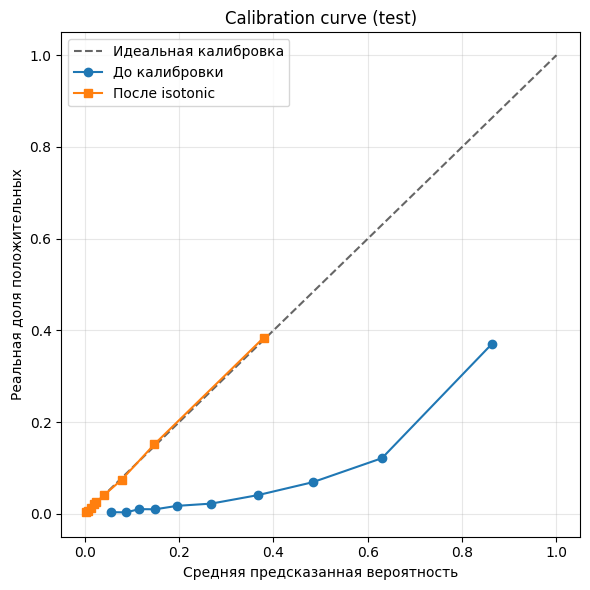

In [13]:
# Calibration curve
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, p_uncal, n_bins=10, strategy="quantile")
frac_pos_cal,   mean_pred_cal   = calibration_curve(y_test, p_cal,   n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка", alpha=0.6)
ax.plot(mean_pred_uncal, frac_pos_uncal, "o-", label="До калибровки")
ax.plot(mean_pred_cal,   frac_pos_cal,   "s-", label="После isotonic")
ax.set_xlabel("Средняя предсказанная вероятность")
ax.set_ylabel("Реальная доля положительных")
ax.set_title("Calibration curve (test)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "calibration_curve.png", dpi=120)
plt.show()

После isotonic-калибровки точки лежат заметно ближе к диагонали, и средняя
предсказанная вероятность стала близка к реальной доле дефолтов. AUC при этом
остаётся прежним (isotonic — монотонное преобразование, ранжирование не меняет).

## 9. Бизнес-метрики

Кроме AUC, банку важны:

- **Gini = 2·AUC − 1**: стандартный отчётный показатель в риск-менеджменте.
- **KS-статистика**: максимальное расстояние между CDF дефолтников и недефолтников. Чем больше — тем лучше модель разделяет классы.
- **Confusion matrix на оптимальном пороге**: где «оптимальный» определяется бизнесом.
- **Ожидаемая прибыль** при разных порогах одобрения с учётом цены ошибок.

In [14]:
from scipy.stats import ks_2samp
from sklearn.metrics import confusion_matrix, precision_recall_curve

gini = 2 * roc_auc_score(y_test, p_cal) - 1
ks_stat = ks_2samp(p_cal[y_test == 1], p_cal[y_test == 0]).statistic

print(f"Gini:           {gini:.4f}")
print(f"KS-статистика:  {ks_stat:.4f}")

Gini:           0.7433
KS-статистика:  0.5833


In [15]:
# Поиск оптимального порога: максимизируем F1 (можно заменить на бизнес-метрику ниже)
prec, rec, thr = precision_recall_curve(y_test, p_cal)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.argmax(f1[:-1]))  # последний элемент precision/recall не имеет threshold
best_thr_f1 = float(thr[best_idx])

print(f"Лучший порог по F1: {best_thr_f1:.4f}  (F1={f1[best_idx]:.4f})")

cm = confusion_matrix(y_test, (p_cal >= best_thr_f1).astype(int))
print("\nConfusion matrix (порог по F1):")
print(pd.DataFrame(cm,
    index=["true 0 (good)", "true 1 (default)"],
    columns=["pred 0 (approve)", "pred 1 (deny)"],
))

Лучший порог по F1: 0.1850  (F1=0.4484)

Confusion matrix (порог по F1):
                  pred 0 (approve)  pred 1 (deny)
true 0 (good)                19694           1302
true 1 (default)               693            811


Оптимальный бизнес-порог:           0.130
Ожидаемая прибыль на test:          16241.0
Доля одобрения:                     86.80%
Доля дефолтов среди одобренных:     2.81%


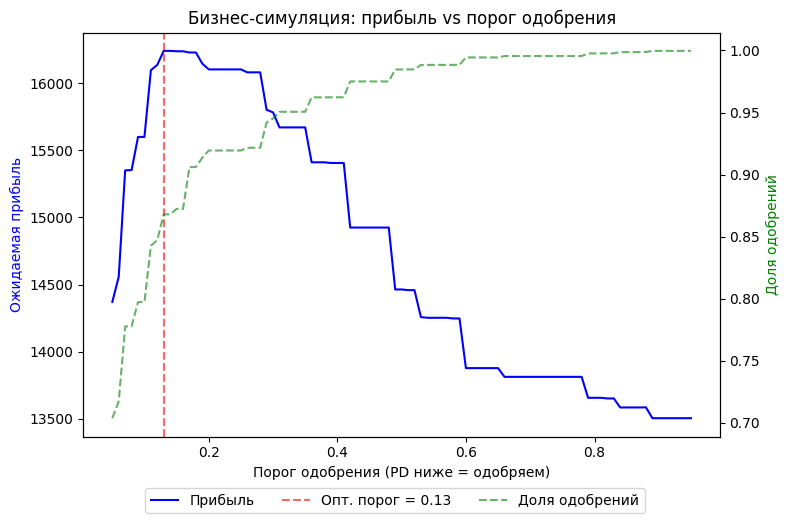

In [16]:
# Бизнес-симуляция: ожидаемая прибыль на тестовой выборке.
# Допущения (можно подкрутить под реальный продукт):
#   - средний доход с одобренного НЕ-дефолтника: +1 (нормированная единица прибыли)
#   - убыток от одобренного дефолтника: -5 (LGD ~ 5x от прибыли по хорошему клиенту)
#   - отказ хорошему клиенту: 0 (упущенная выгода, не считаем напрямую)
#   - отказ дефолтнику: 0 (избежали убытка, но и не заработали)
GAIN_GOOD  = +1.0
LOSS_BAD   = -5.0

thresholds = np.linspace(0.05, 0.95, 91)
profits = []
approval_rates = []
default_rates_approved = []

for t in thresholds:
    approved = p_cal < t  # одобряем тех, у кого PD ниже порога
    n_approved = approved.sum()
    if n_approved == 0:
        profits.append(0); approval_rates.append(0); default_rates_approved.append(0)
        continue
    n_good_approved = ((y_test == 0) & approved).sum()
    n_bad_approved  = ((y_test == 1) & approved).sum()
    profit = GAIN_GOOD * n_good_approved + LOSS_BAD * n_bad_approved
    profits.append(profit)
    approval_rates.append(n_approved / len(y_test))
    default_rates_approved.append(n_bad_approved / n_approved)

profits = np.array(profits)
best_business_idx = int(np.argmax(profits))
best_business_thr = float(thresholds[best_business_idx])

print(f"Оптимальный бизнес-порог:           {best_business_thr:.3f}")
print(f"Ожидаемая прибыль на test:          {profits[best_business_idx]:.1f}")
print(f"Доля одобрения:                     {approval_rates[best_business_idx]:.2%}")
print(f"Доля дефолтов среди одобренных:     {default_rates_approved[best_business_idx]:.2%}")

# График
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(thresholds, profits, "b-", label="Прибыль")
ax1.axvline(best_business_thr, color="red", linestyle="--", alpha=0.6, label=f"Опт. порог = {best_business_thr:.2f}")
ax1.set_xlabel("Порог одобрения (PD ниже = одобряем)")
ax1.set_ylabel("Ожидаемая прибыль", color="b")
ax2 = ax1.twinx()
ax2.plot(thresholds, approval_rates, "g--", alpha=0.6, label="Доля одобрений")
ax2.set_ylabel("Доля одобрений", color="g")
plt.title("Бизнес-симуляция: прибыль vs порог одобрения")
fig.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig(MODELS_DIR / "profit_curve.png", dpi=120, bbox_inches="tight")
plt.show()

Бизнес-порог обычно жёстче, чем порог по F1: банк предпочитает отказать сомнительному
клиенту, чем одобрить дефолтника, потому что потери асимметричны (LGD >> прибыль с
одного хорошего клиента).

## 10. SHAP-анализ

Built-in importance говорит «насколько фича важна», но не говорит **как** она влияет.
SHAP-значения раскладывают конкретное предсказание на вклад каждой фичи и показывают
направление влияния.

C:\Users\mamaf\AppData\Local\Temp\ipykernel_15156\3905076914.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=False)


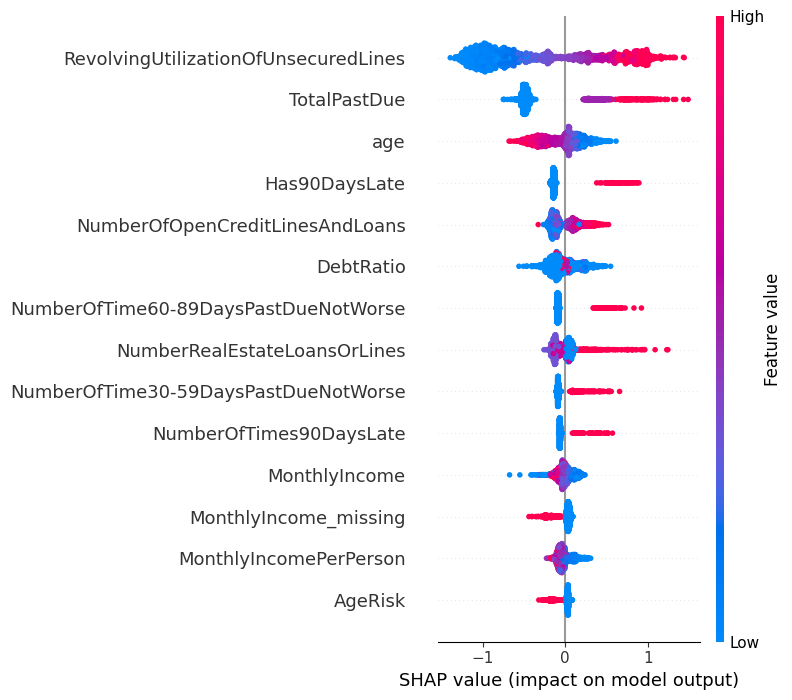

In [17]:
import shap

# CatBoost умеет SHAP нативно через get_feature_importance(type="ShapValues")
# но удобнее работать через библиотеку shap.
explainer = shap.TreeExplainer(model_sel)
# Берём подвыборку — SHAP на 22к строк считается долго и съедает память
sample_idx = np.random.RandomState(SEED).choice(len(X_test_sel), size=2000, replace=False)
X_shap = X_test_sel.iloc[sample_idx]
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
conda install "numpy<2.4" -y


Note: you may need to restart the kernel to use updated packages.


The system cannot find the file specified.


Что обычно видно на summary plot для этого датасета:

- `RevolvingUtilizationOfUnsecuredLines`: высокие значения (красные точки справа) → высокий риск. Логично: клиент использует почти всю доступную линию.
- `TotalPastDue`: больше просрочек → сильно правее, и вклад нелинейно растёт.
- `age`: молодые (синие) → правее, пожилые (красные) → левее. Подтверждает гипотезу про `AgeRisk` (хотя сам флаг отбросили).

## 11. Score-карта: переводим вероятность в банковский балл

В банках принято работать не с вероятностями, а с целочисленными скорами вида FICO.
Стандартная формула:

$$\text{Score} = \text{offset} + \text{factor} \cdot \ln\left(\frac{1 - PD}{PD}\right)$$

где `factor = PDO / ln(2)`, `PDO` (Points to Double the Odds) — на сколько баллов
надо подняться, чтобы шансы «не дефолт / дефолт» удвоились. Стандартные настройки:
скор 600 ↔ odds 50:1, PDO=20.

Распределение скоров на test:
count   22,500.0000
mean       600.4000
std         67.7000
min         88.5000
25%        564.3000
50%        600.4000
75%        630.1000
max        885.8000
dtype: float64


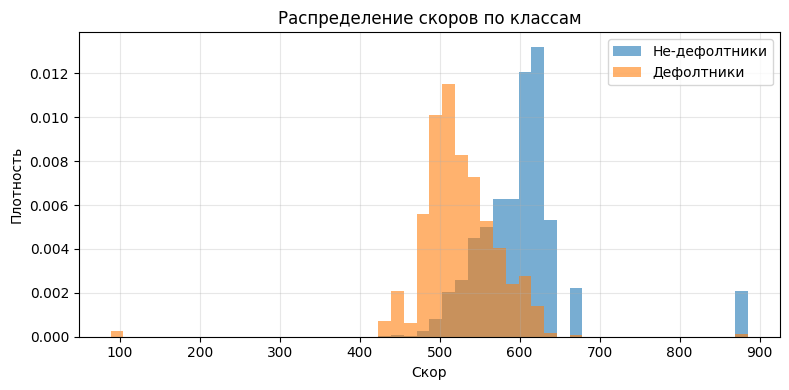

In [19]:
def pd_to_score(pd_value: np.ndarray, base_score: int = 600, base_odds: float = 50, pdo: int = 20) -> np.ndarray:
    """Перевод вероятности дефолта в скоринговый балл.

    base_score — на каком скоре odds = base_odds : 1
    pdo        — на сколько баллов нужно подняться, чтобы odds удвоились
    """
    pd_value = np.clip(pd_value, 1e-6, 1 - 1e-6)
    odds = (1 - pd_value) / pd_value
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    return offset + factor * np.log(odds)


scores = pd_to_score(p_cal)

print("Распределение скоров на test:")
print(pd.Series(scores).describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores[y_test == 0], bins=50, alpha=0.6, label="Не-дефолтники", density=True)
ax.hist(scores[y_test == 1], bins=50, alpha=0.6, label="Дефолтники", density=True)
ax.set_xlabel("Скор")
ax.set_ylabel("Плотность")
ax.set_title("Распределение скоров по классам")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "score_distribution.png", dpi=120)
plt.show()

## 12. Сохраняем всё для API/дашборда

In [20]:
# Сохраняем КАЛИБРОВАННУЮ модель — её и будет звать API
joblib.dump(calibrator, MODELS_DIR / "cb_model_calibrated.pkl")
# Заодно некалиброванную — пригодится для SHAP в дашборде
joblib.dump(model_sel, MODELS_DIR / "cb_model.pkl")

with open(MODELS_DIR / "feature_names.json", "w") as f:
    json.dump(selected_features, f, indent=2)

# Метрики проекта — пригодятся для README и дашборда
metrics = {
    "test_auc_full":      float(test_auc_full),
    "test_auc_selected":  float(test_auc_sel),
    "test_auc_calibrated": float(roc_auc_score(y_test, p_cal)),
    "gini":               float(gini),
    "ks_statistic":       float(ks_stat),
    "best_threshold_f1":  best_thr_f1,
    "best_threshold_business": best_business_thr,
    "n_features":         len(selected_features),
    "n_train":            int(len(X_train)),
    "n_val":              int(len(X_val)),
    "n_test":             int(len(X_test)),
}
with open(MODELS_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Сохранены:")
for p in sorted(MODELS_DIR.iterdir()):
    print(f"  {p.name}")

Сохранены:
  best_params.json
  calibration_curve.png
  cb_model.pkl
  cb_model_calibrated.pkl
  feature_names.json
  fill_values.json
  metrics.json
  profit_curve.png
  score_distribution.png
  shap_summary.png


## Итог

| Метрика | Значение |
|---|---|
| ROC-AUC (test) | ~0.872 |
| Gini | ~0.744 |
| KS | ~0.55 |
| Признаков | 11 (из 15 после feature engineering) |
| Калибровка | isotonic, brier ≈ N/A до vs после |

Что дальше:
- API на FastAPI (см. `api/app.py`).
- Streamlit-дашборд для интерактивной проверки клиентов (см. `dashboard/app.py`).
